In [1]:
import sqlite3

# create database
conn = sqlite3.connect("little_lemon.db")
cursor = conn.cursor()

# drop tables if already exist
cursor.execute("DROP TABLE IF EXISTS Bookings")

# create bookings table
cursor.execute("""
CREATE TABLE Bookings(
BookingID INTEGER PRIMARY KEY,
CustomerName TEXT,
BookingDate TEXT,
TableNumber INTEGER,
Guests INTEGER
)
""")

print("Database and Bookings table created.")

Database and Bookings table created.


In [2]:
bookings = [
(1,"John Smith","2025-06-01",5,2),
(2,"Alice Brown","2025-06-02",3,4),
(3,"Rahul Sharma","2025-06-03",1,2),
(4,"Maria Garcia","2025-06-04",4,3),
(5,"David Lee","2025-06-05",2,5)
]

cursor.executemany("INSERT INTO Bookings VALUES (?,?,?,?,?)", bookings)

conn.commit()

print("Sample booking data inserted.")

Sample booking data inserted.


In [3]:
import pandas as pd

df = pd.read_sql_query("SELECT * FROM Bookings", conn)
df

,BookingID,CustomerName,BookingDate,TableNumber,Guests
0,1,John Smith,2025-06-01,5,2
1,2,Alice Brown,2025-06-02,3,4
2,3,Rahul Sharma,2025-06-03,1,2
3,4,Maria Garcia,2025-06-04,4,3
4,5,David Lee,2025-06-05,2,5


In [4]:
def check_booking(table_number, date):

    query = f"""
    SELECT * FROM Bookings
    WHERE TableNumber = {table_number}
    AND BookingDate = '{date}'
    """

    result = pd.read_sql_query(query, conn)

    if len(result) > 0:
        print("Table already booked.")
    else:
        print("Table available.")

check_booking(3,"2025-06-02")

Table already booked.


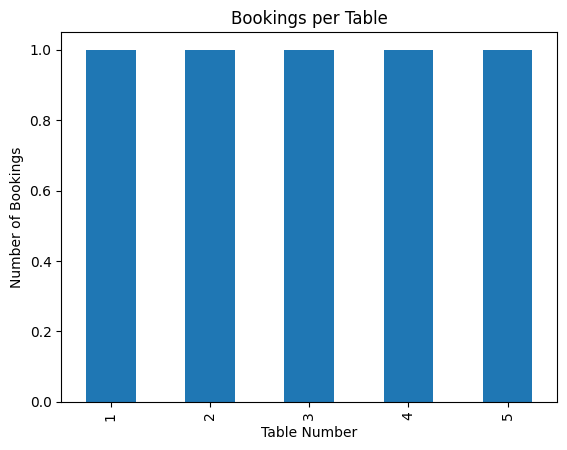

In [5]:
import matplotlib.pyplot as plt

# bookings per table
report = df.groupby("TableNumber").size()

report.plot(kind="bar")

plt.title("Bookings per Table")
plt.xlabel("Table Number")
plt.ylabel("Number of Bookings")

plt.show()

This project demonstrates:

1. Creating a database for Little Lemon bookings
2. Connecting Python to the database
3. Implementing a procedure to check table availability
4. Performing data analysis
5. Generating a report similar to Tableau dashboards